# Description

Notebook to create a sin based dataset

In [127]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('Tesis')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
CURRENT_DIR = os.path.join(CURRENT_DIR, 'S-noise-gradient')
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [128]:
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
from IPython.display import display, clear_output
from tqdm import tqdm
import math
from scipy import stats
import TSFEDL

# Locals
from utils import *
from dataset import BioFuelDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

In [129]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [130]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [131]:
def sin_function(x):
    """
    Function that takes in a value x and returns its sin.
    The values are scaled to be between 0 and 1.

    Args:
        x (float): value to be transformed.

    Returns:
        float: value of sin(x) scaled to be between 0 and 1.
    """

    return (1 + np.sin(np.pi * x))/2


def polinomial_function(x):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def generate_data(num_points, degree, noise=0.1):
    x = np.random.uniform(-1, 1, num_points)
    y_true = np.polyval(np.random.rand(degree + 1), x)
    y_noisy = y_true #+ noise * np.random.randn(num_points)
    return x, y_noisy


def add_gaussian_noise(df, columns, mean=0, std=0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df


In [132]:
df = pd.read_csv(os.path.join(DATA_PATH, 'microsoft_stock', 'Microsoft_Stock.csv'), parse_dates=["Date"], index_col="Date")
df.index = df.index.strftime("%Y-%m-%d")
df.index = pd.to_datetime(df.index)
df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2021-03-25,235.30,236.94,231.57,232.34,34061853
2021-03-26,231.55,236.71,231.55,236.48,25479853
2021-03-29,236.59,236.80,231.88,235.24,25227455
2021-03-30,233.53,233.85,231.10,231.85,24792012
2021-03-31,232.91,239.10,232.39,235.77,43623471


In [133]:
display(df.info())
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1511 entries, 2015-04-01 to 2021-03-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1511 non-null   float64
 1   High    1511 non-null   float64
 2   Low     1511 non-null   float64
 3   Close   1511 non-null   float64
 4   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.8 KB


None

,count,mean,std,min,25%,50%,75%,max
Open,1511.0,1.073860e+02,5.669133e+01,40.34,5.786000e+01,93.99,1.394400e+02,2.450300e+02
High,1511.0,1.084375e+02,5.738228e+01,40.74,5.806000e+01,95.10,1.403250e+02,2.461300e+02
Low,1511.0,1.062945e+02,5.597716e+01,39.72,5.742000e+01,92.92,1.378250e+02,2.429200e+02
Close,1511.0,1.074221e+02,5.670230e+01,40.29,5.785500e+01,93.86,1.389650e+02,2.449900e+02
Volume,1511.0,3.019863e+07,1.425266e+07,101612.00,2.136213e+07,26629615.00,3.431962e+07,1.352271e+08


In [134]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
# df_scaled = df.copy()

Text(0.5, 0, 'Date')

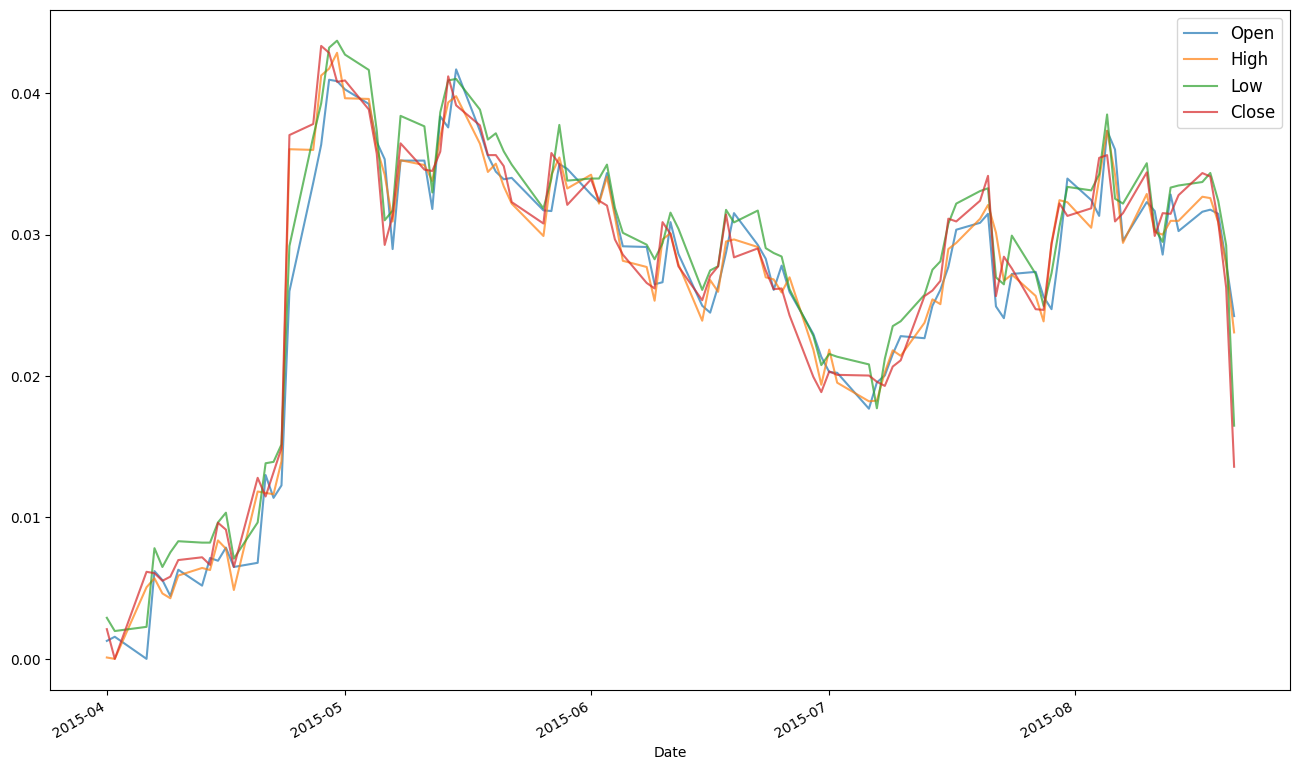

In [135]:
df_scaled.drop(columns=['Volume']).iloc[:100].plot(figsize=(16, 10), alpha=0.7)
plt.legend(fontsize="large")
plt.xlabel("Date")

In [136]:
df = df_scaled

In [137]:
diferencias = df.index.to_series().diff().dropna()
if diferencias.nunique() == 1:
    print("No hay huecos en los datos. Las fechas están equidistantemente separadas.")
else:
    print("Hay huecos en los datos. Las fechas no están equidistantemente separadas.")

Hay huecos en los datos. Las fechas no están equidistantemente separadas.


In [138]:
# Generar todas las fechas esperadas en el rango del índice original
fechas_completas = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Reindexar el DataFrame para incluir todas las fechas
df_reindexado = df.reindex(fechas_completas)

# Rellenar los valores faltantes (por ejemplo, usando interpolación)
df_rellenado = df_reindexado.interpolate(method='linear')

diferencias = df_rellenado.index.to_series().diff().dropna()
if diferencias.nunique() == 1:
    print("No hay huecos en los datos. Las fechas están equidistantemente separadas.")
    df = df_rellenado
else:
    print("Hay huecos en los datos. Las fechas no están equidistantemente separadas.")

No hay huecos en los datos. Las fechas están equidistantemente separadas.


In [167]:
_X_train, X_test, _y_train, y_test = train_test_split(
    df[['Close']], df['Close'],
    test_size=0.2,
    shuffle=False
)
X_train, X_val, y_train, y_val = train_test_split(
    _X_train, _y_train,
    test_size=0.2,
    shuffle=False
)

# y_train = pd.DataFrame(y_train.values.reshape(-1, 1), columns=['meantemp'])
# y_val = pd.DataFrame(y_val.values.reshape(-1, 1), columns=['meantemp'])

window_size = 50
future = 1
sliding_window_train = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=future, mode='range', cnn=False)
sliding_window_val = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=future, mode='range', cnn=False)

In [187]:
batch_size = 32
train_dataloader = DataLoader(sliding_window_train, batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(sliding_window_val, batch_size=batch_size, shuffle=True)

In [188]:
class GeneralRegression(nn.Module):
    """
    Layers to transform any TSFEDL model into a regression model.

    Args:
        nn (Module): PyTorch module inheritance.
    """
    def __init__(self, in_features, output_size):
        super().__init__()
        self.output_size = output_size
        if not isinstance(self.output_size, int):
            self.output_size = output_size[0] * output_size[1]

        self.fc = nn.Linear(in_features, self.output_size)

    def forward(self, x):
        """
        Performs prediction on the input data in matrix format. Default function
        when calling the model().

        Args:
            x (pd.DataFrame): Input data for inference.

        Returns:
            torch.tensor: Tensor with calculated predictions.
        """
        out = self.fc(x)
        # out = self.fc(x[:, -1, :])
        # out = out.view(len(out), self.output_size[0], self.output_size[1])
        return out

class StackedLSTM(nn.Module):
    """
    Basic LSTM model serving as a baseline to surpass.

    Args:
        nn (Module): Inheritance from pytorch module.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size,
                 top_module=None, bidirectional=False):
        """Initializes the attributes of the LSTM model.

        Args:
            input_size (int): Size of input data.
            hidden_size (int): Number of LSTM cells per layer.
            num_layers (int): Number of layers.
            output_size (tuple): Tuple of the form (future, n_vars_to_pred).
        """
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.top_module = top_module

        self.lstm = nn.LSTM(
            self.input_size,
            self.hidden_size,
            self.num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )


    def forward(self, x):
        """Performs prediction on data in matrix format. Default function when calling the model.

        Args:
            x (pd.DataFrame): Input data for inference.

        Returns:
            torch.tensor: Tensor with calculated predictions.
        """
        x, _ = self.lstm(x)

        if self.top_module is not None:
            x = self.top_module(x)
        return x


    def eval_dataloader(self, data_generator):
        """Evaluates input data loaded using a DataLoader.

        Args:
            data_generator (DataLoader): Batch generator.

        Returns:
            torch.tensor: Tensor containing batch predictions.
        """
        predictions = []
        for batch_x, _ in data_generator:
            batch_x = batch_x.to(self.lstm.weight_ih_l0.device, dtype=torch.float32)
            predictions.append(self.forward(batch_x))

        return predictions


class LSTM_FC(nn.Module):
    """
    LSTM model with fully connected layers and normalization layers.

    Args:
        nn (Module): Inheritance from pytorch module.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        """Initializes the attributes of the LSTM model.

        Args:
            input_size (int): Size of input data.
            hidden_size (int): Number of LSTM cells per layer.
            num_layers (int): Number of layers.
            output_size (tuple): Tuple of the form (future, n_vars_to_pred).
        """
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(self.hidden_size, 256)
        self.bn1 = nn.BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.dp1 = nn.Dropout(0.25)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.dp2 = nn.Dropout(0.2)

        self.relu = nn.ReLU()

        self.fc3 = nn.Linear(128, self.output_size)


    def forward(self, x):
        """Performs prediction on data in matrix format. Default function when calling the model.

        Args:
            x (pd.DataFrame): Input data for inference.

        Returns:
            torch.tensor: Tensor with calculated predictions.
        """
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        lstm_out, _ = self.lstm(x, (h0, c0))

        x0 = self.fc1(lstm_out[:, -1, :])
        x0 = self.bn1(x0)
        x0 = self.dp1(x0)
        x0 = self.relu(x0)

        x0 = self.fc2(x0)
        x0 = self.bn2(x0)
        x0 = self.dp2(x0)
        x0 = self.relu(x0)

        out = self.fc3(x0)
        # out = out.view(len(out), self.output_size[0], self.output_size[1])

        return out


    def eval_dataloader(self, data_generator):
        """Evaluates input data loaded using a DataLoader.

        Args:
            data_generator (DataLoader): Batch generator.

        Returns:
            torch.tensor: Tensor containing batch predictions.
        """
        predictions = []
        for batch_x, _ in data_generator:
            batch_x = batch_x.to(self.lstm.weight_ih_l0.device, dtype=torch.float32)
            predictions.append(self.forward(batch_x))

        return predictions

In [189]:
# Parámetros del modelo
input_size = X_train.shape[1]
hidden_size = 64
num_layers = 16
output_size = future

# Definir el criterio y el optimizador
criterion = nn.MSELoss()
model = LSTM_FC(input_size, hidden_size, num_layers, future)
model.to(device)

lr = 0.001
optimizer = optim.Adam(model.parameters(), lr=lr)

In [190]:

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=10,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'lstm_microsft_stock'),
)

In [191]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:   4%| | 18/500 [00:19<08:36,  1.07s/epoch, Train loss: 0.0134609312

Training stopped as validation loss did not improve for 10 epochs.


In [186]:
best_val_loss

0.17404580076535542

In [21]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'lstm_microsft_stock.pth')))

In [151]:
sliding_window_test = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1, mode='range', cnn=True)
test_dataloader = DataLoader(sliding_window_test, batch_size=16, shuffle=False)

In [152]:
y_pred_test = trainer_basic.eval_dataloader(test_dataloader)
y_pred_test = torch.cat(y_pred_test, dim=0).cpu().detach().numpy()

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/torch/nn/modules/rnn.py:879: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /opt/conda/conda-bld/pytorch_1699449183005/work/aten/src/ATen/native/cudnn/RNN.cpp:982.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


In [153]:
# Especificar el tamaño del DataFrame
n_filas = y_test.shape[0]
n_columnas = df.shape[1]

# Crear un DataFrame lleno de NaNs
df_pred = pd.DataFrame(np.nan, index=range(n_filas), columns=df.columns)
df_real = df_pred.copy()


df_pred['Close'].iloc[-len(y_pred_test):] = y_pred_test.squeeze()
df_real['Close'] = y_test.values

df_pred = pd.DataFrame(scaler.inverse_transform(df_pred)[:,-2], columns=X_test.columns, index=X_test.index)
df_real = pd.DataFrame(scaler.inverse_transform(df_real)[:,-2], columns=X_test.columns, index=X_test.index)

df_pred = df_pred['Close'].dropna()

In [154]:
y_pred = df_pred.values
y_real = df_real['Close'].iloc[-len(y_pred):]

mse = mean_squared_error(y_real, y_pred)
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)
mape = mean_absolute_percentage_error(y_real, y_pred)
rmse = math.sqrt(mse)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")
print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

MSE: 1687.9178765783256
MAE: 38.94037387782149
R2: -1.8544932664099356
MAPE: 0.18433283202313722
RMSE: 41.08427772978765
